In [9]:
##USE conda environment tf
# conda activate tf

import anndata as ad
import scanpy as sc
from matplotlib import rcParams
import pandas as pd
import h5py
import IPython
import bardensr.plotting
import numpy as np
import SimpleITK as sitk
import numpy as np
import tensorflow as tf
import bardensr.preprocessing
import harmonypy

In [10]:
import numpy as np

def rotate_points(spatial, theta):
    # Define the rotation matrix
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])
    
    # Rotate the points
    rotated_points = spatial @ rotation_matrix.T
    
    return rotated_points

# Example usage
# Create a set of points (for example)
spatial = np.array([[1, 0], [0, 1], [-1, 0], [0, -1]])

# Define the rotation angle (in radians)
theta = np.pi / 4  # 45 degrees

# Rotate the points
rotated_spatial = rotate_points(spatial, theta)
print(rotated_spatial)

def open_hdf5(file_path): #assumes this is a list of np arrays
    var_name= []
    f = h5py.File(file_path)
    print(f)
    data = f['list']
    for i in range(len(data)):
        var_name.append(data[str(i)][:])
    f.close()
    print(len(var_name))
    print(len(var_name[0]))
    return var_name

[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]
 [-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]


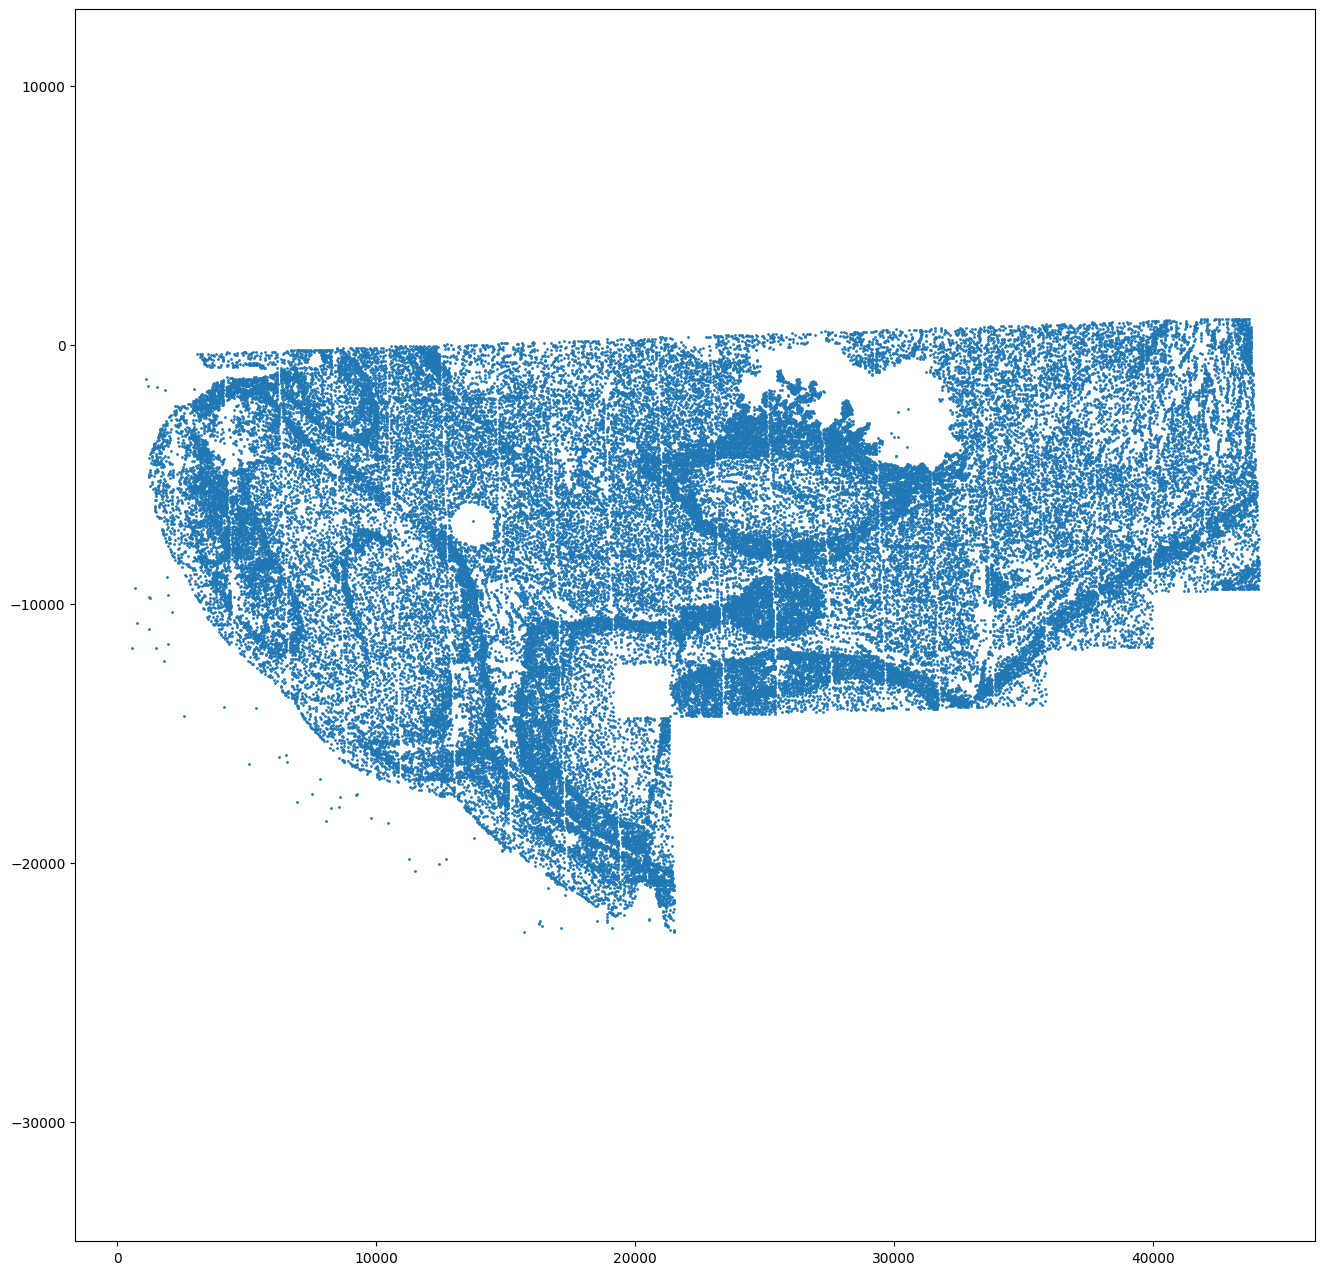

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
import anndata as ad

# Load
p4_1 = ad.read_h5ad("../../../mouse/p56/ma41_p56_a2/new_pipeline/output/adata.h5ad")
p4_1.obs["library_id"] = "p56_1"
p4_1.obs["timepoint"] = "p4"
p4_1.obs["batch"] = "batch3"

# Rotate
p4_1.obsm["spatial"] = rotate_points(
    p4_1.obsm["spatial"],
    (270 / 180) * np.pi
)

# Initial rectangular crop
coords = p4_1.obsm["spatial"]

rect_mask = (
    (coords[:, 1] > -12000) &
    (coords[:, 0] > 10000)
)

p4_1_corr = p4_1#[rect_mask].copy()

# Plot to help choose polygon vertices
coords_corr = p4_1_corr.obsm["spatial"]

plt.figure(figsize=(16, 16))
plt.scatter(coords_corr[:, 0], coords_corr[:, 1], s=1)
plt.axis("equal")
plt.show()



/tmp/ipykernel_2492047/563541998.py:24: ImplicitModificationWarning: Setting element `.obsm['spatial3d']` of view, initializing view as actual.
  p4_2_corr.obsm['spatial3d'] = np.zeros([len(p4_2_corr),3])


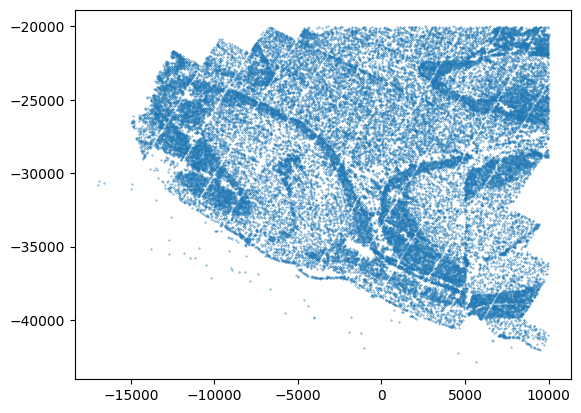

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
import anndata as ad

# Load
p4_2 = ad.read_h5ad("../../../mouse/p56/ma41_p56_a3/new_pipeline/output/adata.h5ad")
p4_2.obs["library_id"] = "p56_2"
p4_2.obs["timepoint"] = "p4"
p4_2.obs["batch"] = "batch3"

p4_2.obsm['spatial'] = rotate_points(p4_2.obsm['spatial'], (240/180)*3.14)
p4_2_coor = p4_2.obsm['spatial'][p4_2.obsm['spatial'][:,1] <-20000]
p4_2_coor = p4_2_coor[p4_2_coor[:,0] <10000]

plt.scatter(p4_2_coor[:,0],p4_2_coor[:,1], s= 0.1)


# Convert e13_1_coor to a list of tuples for faster lookups
p4_2_coor_set = {tuple(coord) for coord in p4_2_coor}
mask = np.array([tuple(coord) in p4_2_coor_set for coord in p4_2.obsm['spatial']])
p4_2_corr = p4_2[mask]

p4_2_corr.obsm['spatial3d'] = np.zeros([len(p4_2_corr),3])
x = p4_2_corr.obsm['spatial'][:,0]
y = p4_2_corr.obsm['spatial'][:,1]
p4_2_corr.obsm['spatial'][:,0] = (x - np.min(x))
p4_2_corr.obsm['spatial'][:,1] = (y - np.min(y))
p4_2_corr.obsm['spatial'][:,1] = (np.max(y) - y)

p4_2_corr.obsm['spatial3d'][:,0] = (x - np.min(x))
p4_2_corr.obsm['spatial3d'][:,1] = (y - np.min(y))
p4_2_corr.obsm['spatial3d'][:,2] = 0

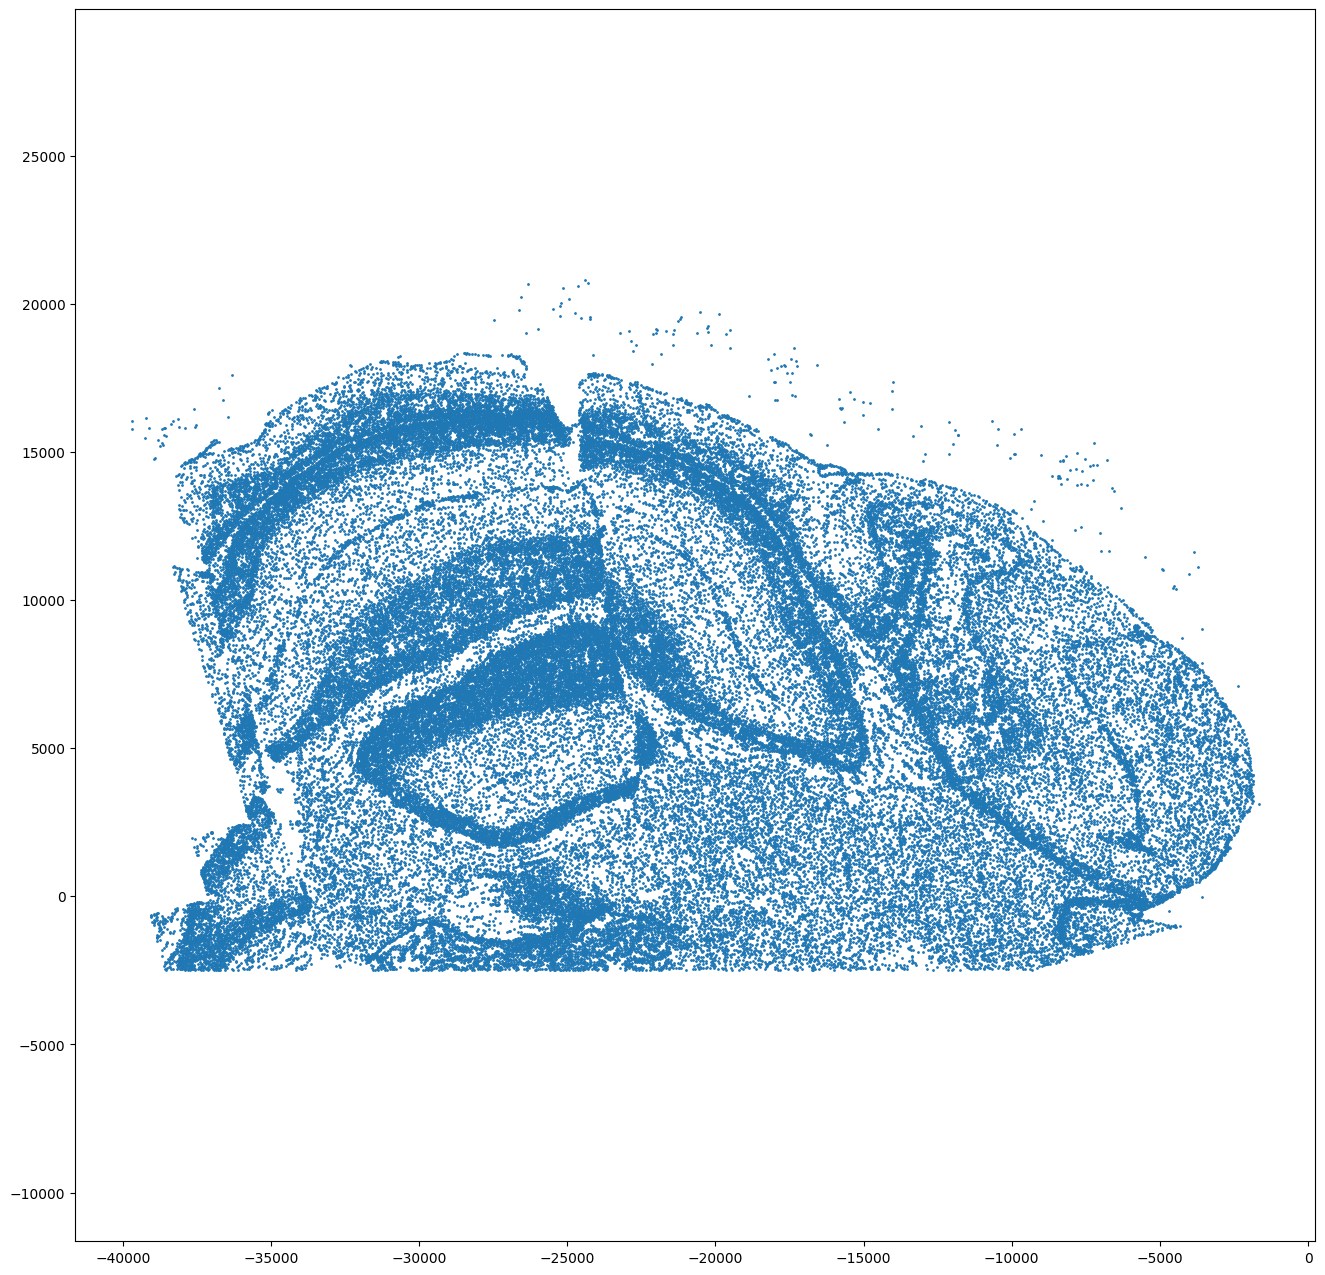

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
import anndata as ad

# Load
p4_3 = ad.read_h5ad("../../../mouse/p56/ma41_p56_d4/new_pipeline/output/adata.h5ad")
p4_3.obs["library_id"] = "p56_3"
p4_3.obs["timepoint"] = "p4"
p4_3.obs["batch"] = "batch3"

# Rotate
p4_3.obsm["spatial"] = rotate_points(
    p4_3.obsm["spatial"],
    (105 / 180) * np.pi
)

# Initial rectangular crop
coords = p4_3.obsm["spatial"]

rect_mask = (
    (coords[:, 1] > -2500)# &
    #(coords[:, 0] > 10000)
)

p4_3_corr = p4_3[rect_mask].copy()

# Plot to help choose polygon vertices
coords_corr = p4_3_corr.obsm["spatial"]

plt.figure(figsize=(16, 16))
plt.scatter(coords_corr[:, 0], coords_corr[:, 1], s=1)
plt.axis("equal")
plt.show()



In [14]:
adata = ad.concat([p4_1_corr, p4_2_corr, p4_3_corr])
adata.obs = adata.obs.reset_index(drop=True)


/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [15]:
sc.pp.calculate_qc_metrics(
    adata,percent_top=None, log1p=False, inplace=True
)
sc.pp.calculate_qc_metrics(
    adata,percent_top=None, log1p=False, inplace=True
)
#sc.pp.filter_cells(adata, min_counts=5)
#sc.pp.filter_genes(adata, min_cells=10)


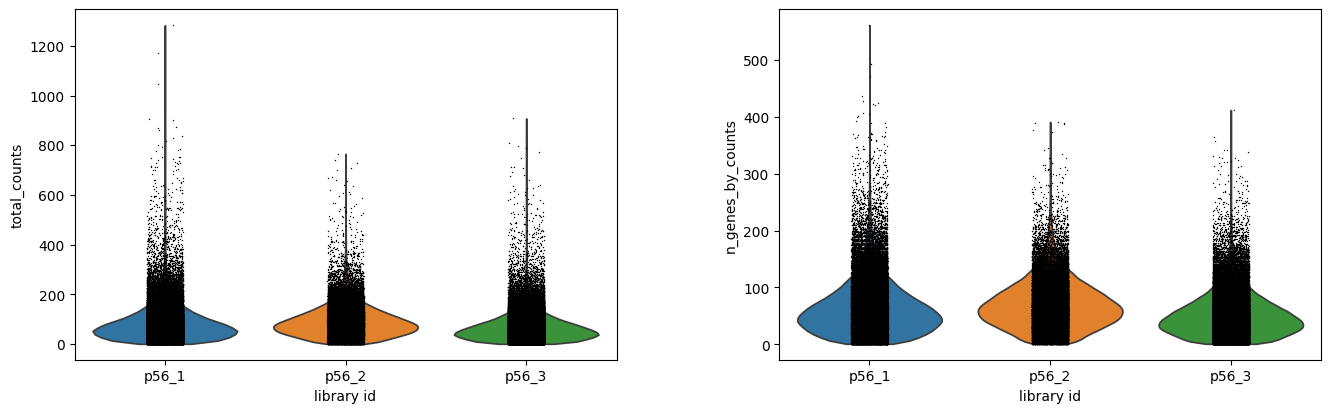

In [16]:
sc.pl.violin(adata, keys=["total_counts", "n_genes_by_counts"], groupby="library_id")

In [28]:
p4_alltp = sc.read_h5ad("../all_tp/p56_1_all_tp_ct.h5ad")

mapping = p4_alltp.obs.set_index("cell_number")["cell_types"]

p4_2_corr.obs["cell_types"] = mapping.reindex(p4_2_corr.obs_names)

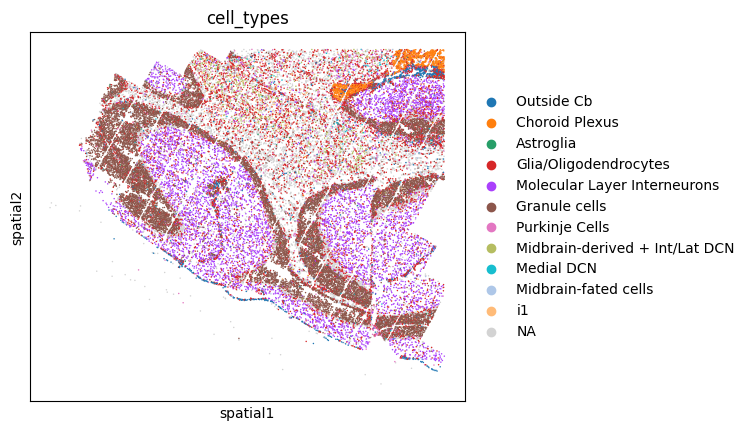

In [30]:
sc.pl.spatial(p4_2_corr, color = "cell_types", spot_size = 100)

/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


predicted_cell_types
Granule cells                     85272
Glia/Oligodendrocytes             55159
Molecular Layer Interneurons      29103
Choroid Plexus                     5166
Purkinje Cells                     3329
Midbrain-derived + Int/Lat DCN     2679
Outside Cb                         1973
i1                                 1077
Midbrain-fated cells                952
Medial DCN                           98
Name: count, dtype: int64
count    184808.000000
mean          0.738338
std           0.210605
min           0.180849
25%           0.546792
50%           0.789563
75%           0.934437
max           1.000000
Name: predicted_max_prob, dtype: float64


/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scipy/sparse/_index.py:146: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


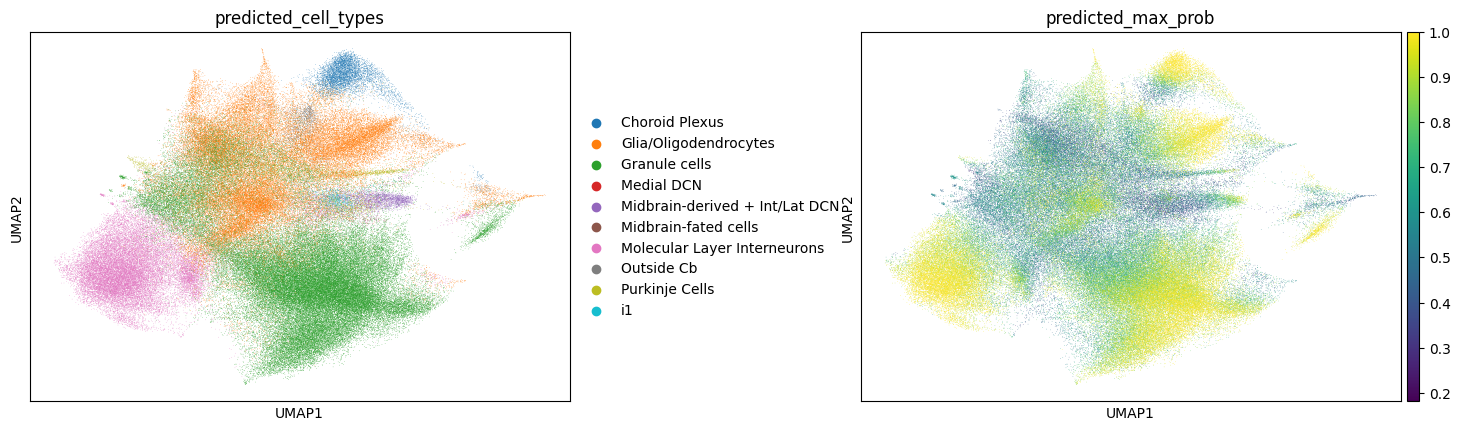

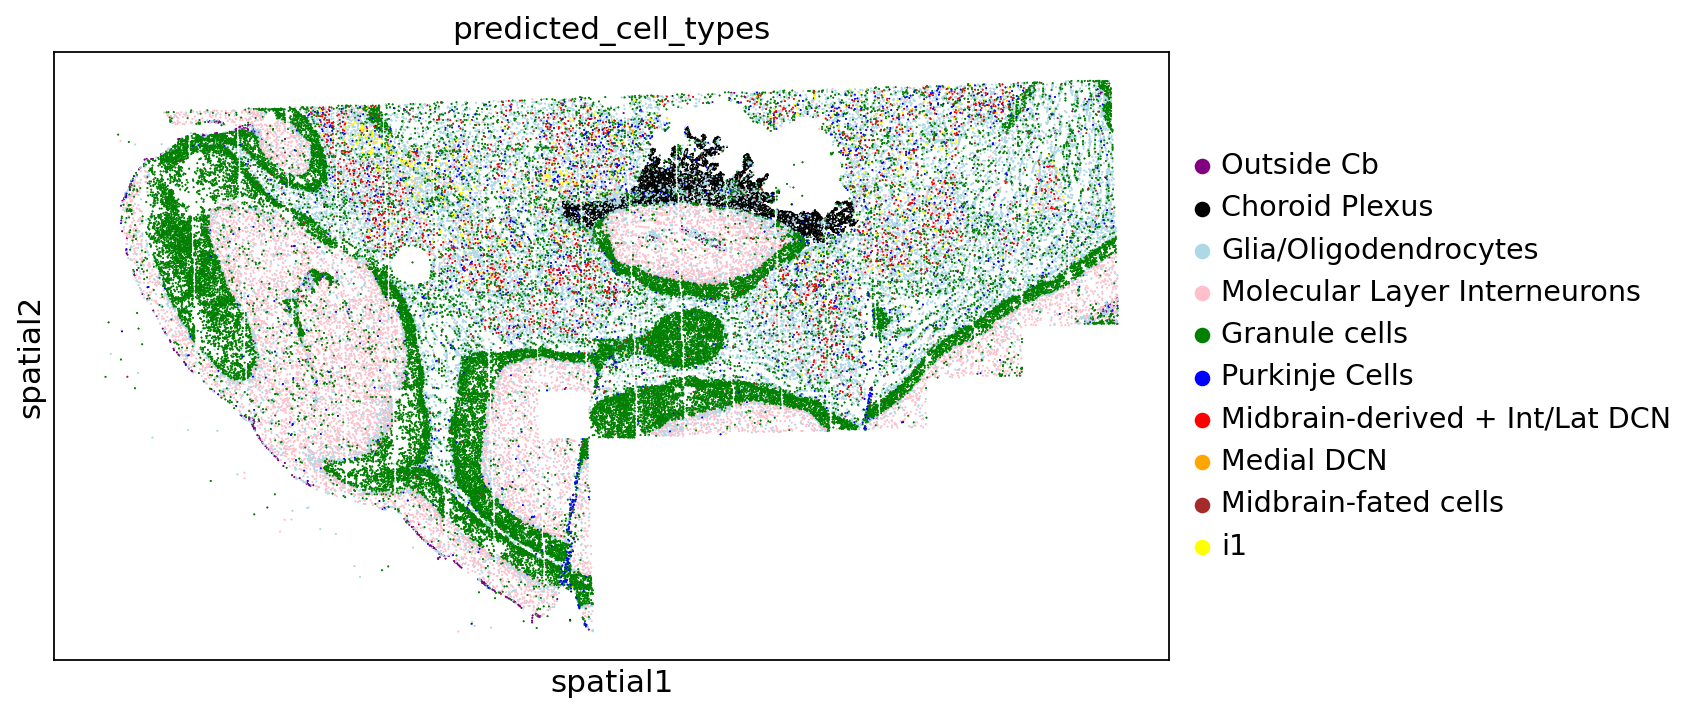

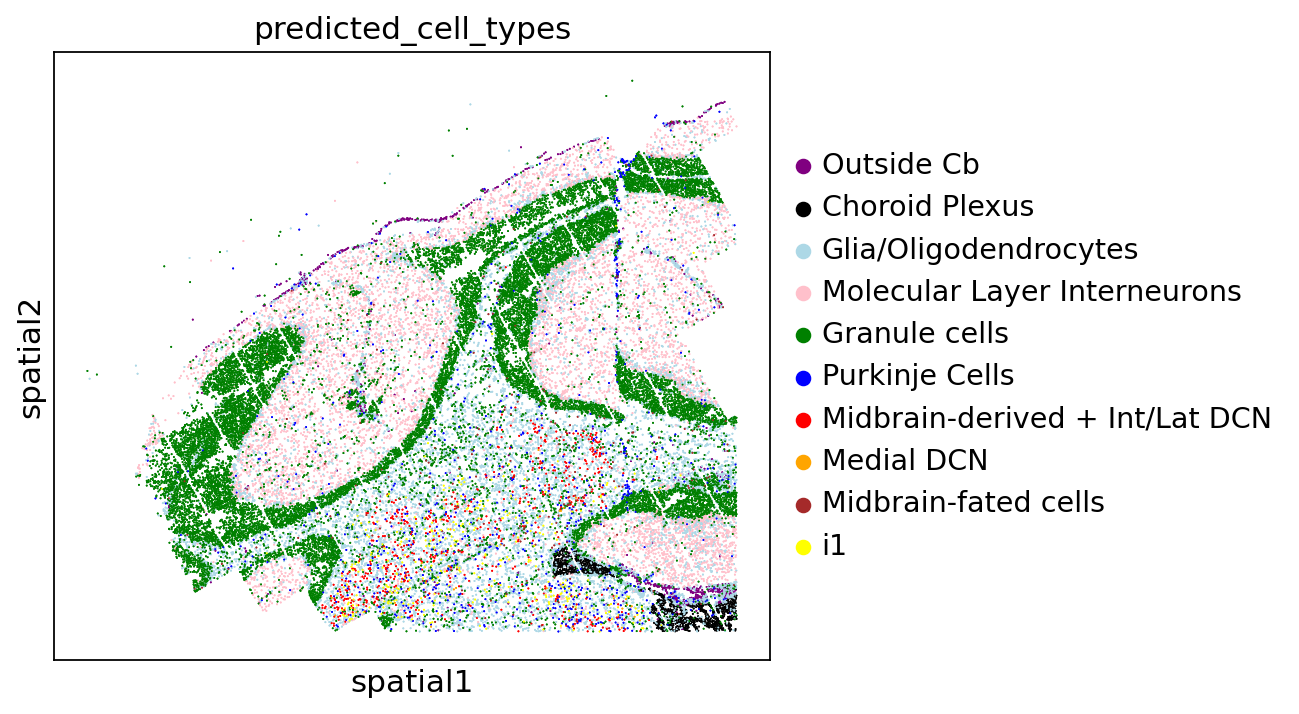

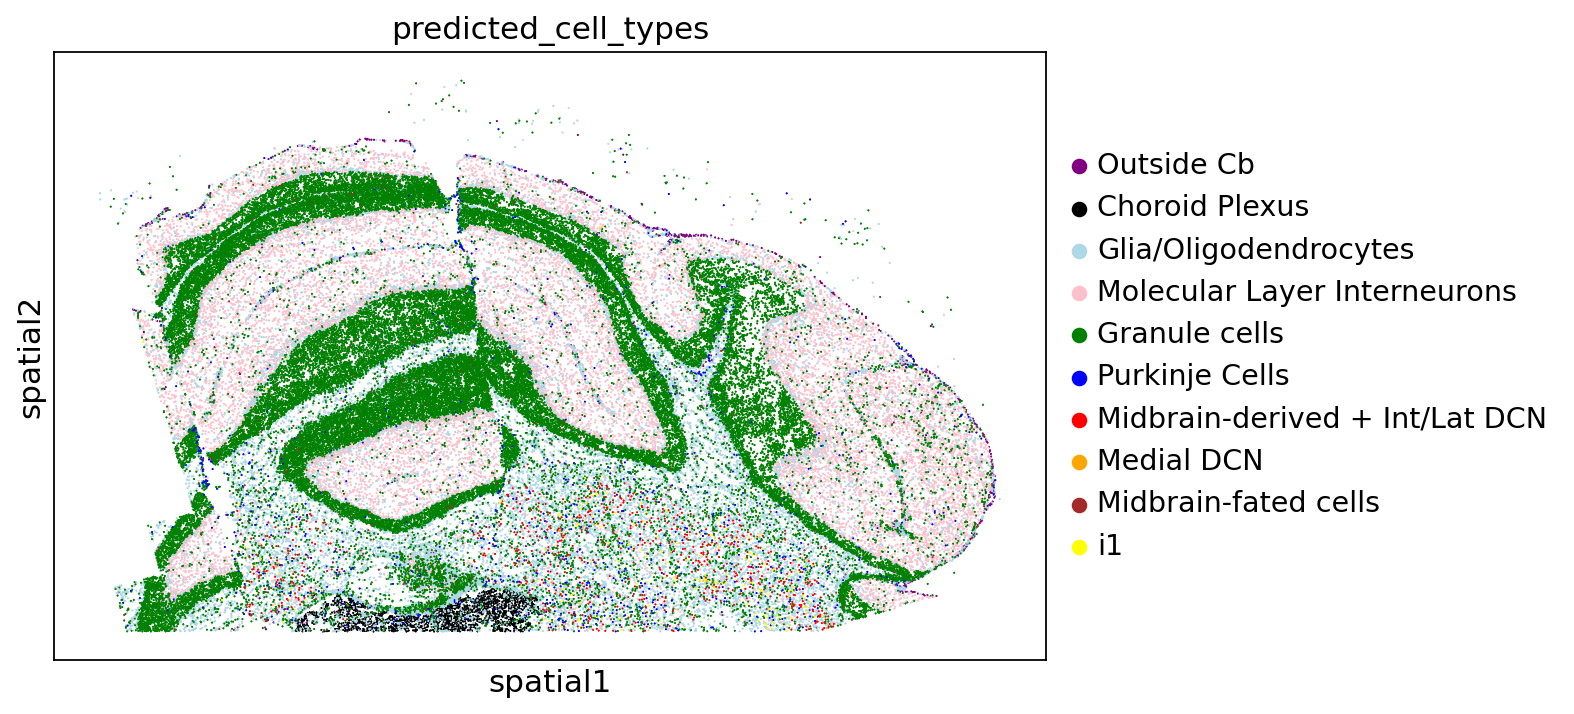

In [31]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.neighbors import KNeighborsClassifier
from scipy import sparse

# =========================================================
# 1. PREP REFERENCE + QUERY
# =========================================================
ref = p4_2_corr.copy()
query = adata.copy()

# keep only labeled ref cells
ref = ref[~ref.obs["cell_types"].isna()].copy()
ref.obs["cell_types"] = pd.Categorical(
    ref.obs["cell_types"].astype(str)
).remove_unused_categories()

# shared genes, same order
shared = ref.var_names.intersection(query.var_names)
ref = ref[:, shared].copy()
query = query[:, shared].copy()

# normalize + log
for x in [ref, query]:
    sc.pp.normalize_total(x)
    sc.pp.log1p(x)

# HVGs from reference only
sc.pp.highly_variable_genes(ref, n_top_genes=3000, flavor="seurat")
hvg = ref.var["highly_variable"].values

ref = ref[:, hvg].copy()
query = query[:, hvg].copy()

# dense matrices if needed
X_ref = ref.X.toarray() if sparse.issparse(ref.X) else np.asarray(ref.X)
X_query = query.X.toarray() if sparse.issparse(query.X) else np.asarray(query.X)

# =========================================================
# 2. SCALE USING REFERENCE STATS
# =========================================================
ref_means = X_ref.mean(axis=0)
ref_stds = X_ref.std(axis=0)
ref_stds[ref_stds == 0] = 1

X_ref_scaled = (X_ref - ref_means) / ref_stds
X_query_scaled = (X_query - ref_means) / ref_stds

ref.X = X_ref_scaled
query.X = X_query_scaled

# =========================================================
# 3. PCA ON REFERENCE, PROJECT QUERY INTO SAME PC SPACE
# =========================================================
sc.tl.pca(ref, n_comps=30)

X_ref_pca = ref.obsm["X_pca"]
loadings = ref.varm["PCs"][:, :30]   # genes x PCs
X_query_pca = X_query_scaled @ loadings

ref.obsm["X_pca_ref"] = X_ref_pca
query.obsm["X_pca_ref"] = X_query_pca

# =========================================================
# 4. KNN LABEL TRANSFER IN PC SPACE
# =========================================================
y_ref = ref.obs["cell_types"].astype(str).values

knn = KNeighborsClassifier(n_neighbors=15, weights="distance")
knn.fit(X_ref_pca, y_ref)

pred = knn.predict(X_query_pca)
probs = knn.predict_proba(X_query_pca)

query.obs["predicted_cell_types"] = pred
query.obs["predicted_max_prob"] = probs.max(axis=1)

# optional: reject low-confidence cells
threshold = 0.0
query.obs["predicted_cell_types"] = np.where(
    query.obs["predicted_max_prob"] < threshold,
    "Unknown",
    query.obs["predicted_cell_types"]
)

query.obs["predicted_cell_types"] = pd.Categorical(query.obs["predicted_cell_types"])

# quick checks
print(query.obs["predicted_cell_types"].value_counts())
print(query.obs["predicted_max_prob"].describe())


# =========================================================
# 5. OPTIONAL UMAP OF TRANSFERRED LABELS
# =========================================================
sc.pp.neighbors(query, use_rep="X_pca_ref", n_neighbors=15)
sc.tl.umap(query)

sc.pl.umap(
    query,
    color=["predicted_cell_types", "predicted_max_prob"],
    wspace=0.4
)

# =========================================================
# 6. COLOR MAP + PLOTTING STYLE
# =========================================================
custom_colors = {
    "Purkinje Cells": "blue",
    "Midbrain-derived + Int/Lat DCN": "red",
    "Medial DCN": "orange",
    "DCN": "orange",
    "Astroglia": "grey",
    "": "white",
    "Choroid Plexus": "black",
    "Granule cells": "green",
    "Midbrain-fated cells": "brown",
    "Molecular Layer Interneurons": "pink",
    "Outside Cb": "purple",
    "Glia/Oligodendrocytes": "lightblue",
    "i1": "yellow",
    "Unknown": "#BBBBBB",
}

desired_order = [
    "Outside Cb",
    "Choroid Plexus",
    "Astroglia",
    "Glia/Oligodendrocytes",
    "Molecular Layer Interneurons",
    "Granule cells",
    "DCN",
    "Purkinje Cells",
    "",
    "Midbrain-derived + Int/Lat DCN",
    "Medial DCN",
    "Midbrain-fated cells",
    "i1",
    "Unknown",
]

to_plot = [
    ("p4_1",  80,  "all_tp_e11"),
    ("p4_2",  80,  "all_tp_e11"),
    ("p4_3",  80,  "all_tp_e11"),
]

def set_colors(adata, key, color_map):
    adata.obs[key] = adata.obs[key].astype("category")
    cats = list(adata.obs[key].cat.categories)

    color_map = dict(color_map)
    for c in cats:
        if c not in color_map:
            color_map[c] = "#CCCCCC"

    adata.uns[f"{key}_colors"] = [mcolors.to_hex(color_map[c]) for c in cats]

def set_order(adata, key, desired_order):
    ct = adata.obs[key].astype("category")
    cur = list(ct.cat.categories)
    final_order = [c for c in desired_order if c in cur] + [c for c in cur if c not in desired_order]

    color_by_cat = dict(zip(cur, adata.uns[f"{key}_colors"]))
    adata.uns[f"{key}_colors"] = [color_by_cat[c] for c in final_order]
    adata.obs[key] = ct.cat.reorder_categories(final_order, ordered=True)

def spatial_overlay_in_order(
    ad, color="predicted_cell_types", order=None, spot_size=80,
    legend_loc="right margin", save=None, show=True
):
    ad.obs[color] = ad.obs[color].astype("category")

    cats_present = [c for c in ad.obs[color].cat.categories if (ad.obs[color] == c).any()]
    draw_order = [c for c in (order or cats_present) if c in cats_present]

    if not draw_order:
        print("[warn] no matching categories in this slice; drawing base only")
        sc.pl.spatial(ad, color=color, spot_size=spot_size, show=show)
        return

    # base layer
    sc.pl.spatial(
        ad,
        color=color,
        spot_size=spot_size,
        na_color="#DDDDDD",
        legend_loc=None,
        show=False
    )
    ax = plt.gca()

    # overlay each category in chosen order
    for g in draw_order:
        sc.pl.spatial(
            ad,
            color=color,
            groups=[g],
            spot_size=spot_size,
            na_color="none",
            ax=ax,
            legend_loc=None,
            title=None,
            show=False
        )

    # legend pass
    sc.pl.spatial(
        ad,
        color=color,
        spot_size=0,
        ax=ax,
        legend_loc=legend_loc,
        na_in_legend=False,
        show=False
    )

    if save:
        plt.savefig(save, bbox_inches="tight", dpi=300)
    if show:
        plt.show()
    plt.close()

# apply colors + order once to full query object
set_colors(query, "predicted_cell_types", custom_colors)
set_order(query, "predicted_cell_types", desired_order)

# =========================================================
# 7. PLOT ALL SLICES WITH SAME COLORS/ORDER
# =========================================================
sc.set_figure_params(figsize=(15, 5))

for lib_id, spot, suffix in to_plot:
    ad = query[query.obs["library_id"] == lib_id].copy()
    if ad.n_obs == 0:
        print(f"[warn] No cells for library_id={lib_id}, skipping")
        continue

    # preserve full global category order + colors
    ad.obs["predicted_cell_types"] = ad.obs["predicted_cell_types"].cat.set_categories(
        query.obs["predicted_cell_types"].cat.categories,
        ordered=True
    )
    ad.uns["predicted_cell_types_colors"] = query.uns["predicted_cell_types_colors"]

    spatial_overlay_in_order(
        ad,
        color="predicted_cell_types",
        order=desired_order,
        spot_size=spot,
        show=True,
        # save=f"{suffix}_predicted_overlay.pdf",
    )
